In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)


# Load test data
X_test = pd.read_csv(Path(r"data/X_test_selected.csv"))
y_test = pd.read_csv(Path(r"data/y_test.csv")).squeeze("columns")

# Load trained models
logreg_model = joblib.load(Path(r"models/logreg_model.joblib"))
rf_model = joblib.load(Path(r"models/rf_model.joblib"))
xgb_model = joblib.load(Path(r"models/xgb_model.joblib"))

models = {
    "Logistic Regression": logreg_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

print("Data and models loaded.")

c:\Users\migue\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\migue\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Data and models loaded.


c:\Users\migue\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\migue\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [11:47:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\data\../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/

## Predictions com os 3 modelos

In [2]:
results = []
predictions_dict = {}

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    predictions_dict[model_name] = {
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)

print("Final test-set results:")
display(results_df)

Final test-set results:


,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost,0.608869,0.192813,0.735350,0.305517,0.743816
1,Random Forest,0.696450,0.223714,0.645558,0.332279,0.736637
0,Logistic Regression,0.593055,0.185310,0.729679,0.295559,0.723144


## Classification reports e confusion matrixes finais


Logistic Regression


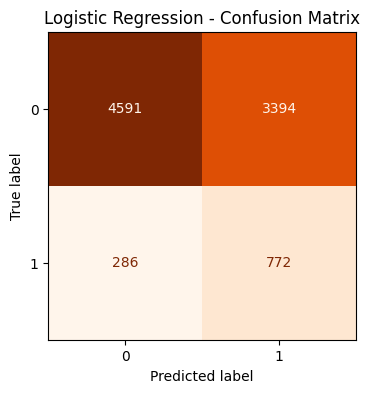


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.57      0.71      7985
           1       0.19      0.73      0.30      1058

    accuracy                           0.59      9043
   macro avg       0.56      0.65      0.50      9043
weighted avg       0.85      0.59      0.66      9043


Random Forest


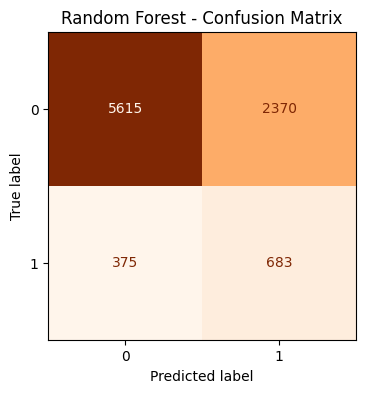


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.70      0.80      7985
           1       0.22      0.65      0.33      1058

    accuracy                           0.70      9043
   macro avg       0.58      0.67      0.57      9043
weighted avg       0.85      0.70      0.75      9043


XGBoost


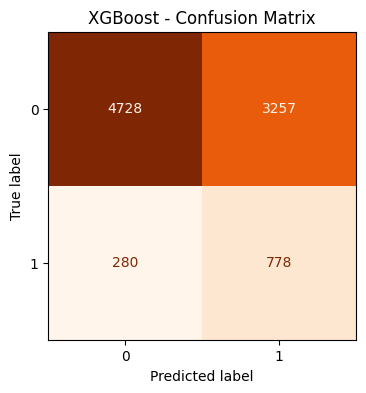


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.59      0.73      7985
           1       0.19      0.74      0.31      1058

    accuracy                           0.61      9043
   macro avg       0.57      0.66      0.52      9043
weighted avg       0.86      0.61      0.68      9043



In [3]:
for model_name, preds in predictions_dict.items():
    print(f"\n{'='*60}")
    print(model_name)
    print(f"{'='*60}")

    # Confusion matrix
    cm = confusion_matrix(y_test, preds["y_pred"])

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot(
        ax=ax,
        cmap="Oranges",
        colorbar=False,
        values_format="d"
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, preds["y_pred"]))

## ROC Curve

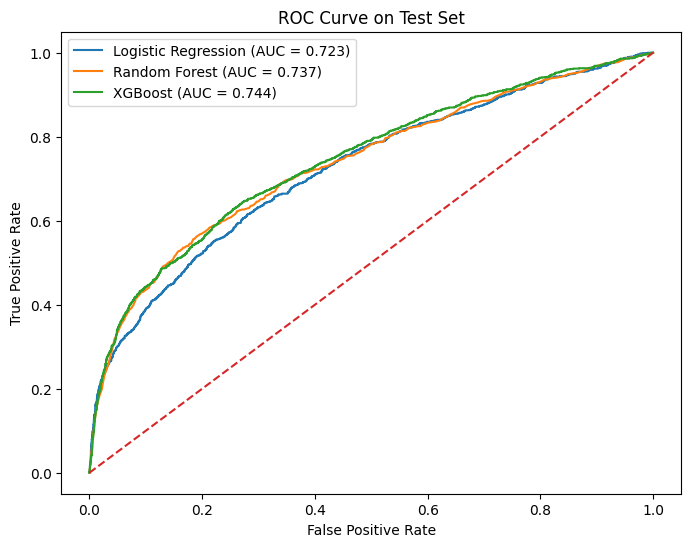

In [4]:
plt.figure(figsize=(8, 6))

for model_name, preds in predictions_dict.items():
    fpr, tpr, _ = roc_curve(y_test, preds["y_prob"])
    auc_score = roc_auc_score(y_test, preds["y_prob"])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set")
plt.legend()
plt.show()

## Final feature importances para Random Forest e XGboost

In [5]:
feature_names = X_test.columns

# Random Forest feature importance
rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Random Forest - Top 15 Feature Importances")
display(rf_importance.head(15))

# XGBoost feature importance
xgb_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("XGBoost - Top 15 Feature Importances")
display(xgb_importance.head(15))

Random Forest - Top 15 Feature Importances


,feature,importance
1,balance,0.260377
0,age,0.196393
2,campaign,0.097977
20,housing_yes,0.083253
3,pdays,0.063182
4,previous,0.059484
24,poutcome_success,0.029042
15,marital_married,0.028791
5,job_blue-collar,0.023237
21,loan_yes,0.020188


XGBoost - Top 15 Feature Importances


,feature,importance
24,poutcome_success,0.232582
4,previous,0.153069
20,housing_yes,0.126437
3,pdays,0.050164
15,marital_married,0.043916
18,education_tertiary,0.042330
0,age,0.027525
2,campaign,0.025554
23,poutcome_other,0.024430
5,job_blue-collar,0.023503


## Final feature importances para logistic regression

In [6]:
logreg_importance = pd.DataFrame({
    "feature": X_test.columns,
    "coefficient": logreg_model.coef_[0],
    "abs_coefficient": np.abs(logreg_model.coef_[0])
}).sort_values("abs_coefficient", ascending=False)

print("Logistic Regression - Top 15 Coefficients by Absolute Value")
display(logreg_importance.head(15))

Logistic Regression - Top 15 Coefficients by Absolute Value


,feature,coefficient,abs_coefficient
1,balance,8.438218,8.438218
2,campaign,-8.375260,8.375260
4,previous,5.429017,5.429017
24,poutcome_success,4.368143,4.368143
12,job_student,1.548138,1.548138
9,job_retired,1.246494,1.246494
20,housing_yes,-1.214091,1.214091
18,education_tertiary,0.937669,0.937669
0,age,-0.934634,0.934634
23,poutcome_other,0.844687,0.844687


## SHAP analysis

Esta análise ajuda a perceber as decisões do modelo e os features que contribuem mais e de que forma para ser positivo ou negativo

### SHAP para Logistic Regression

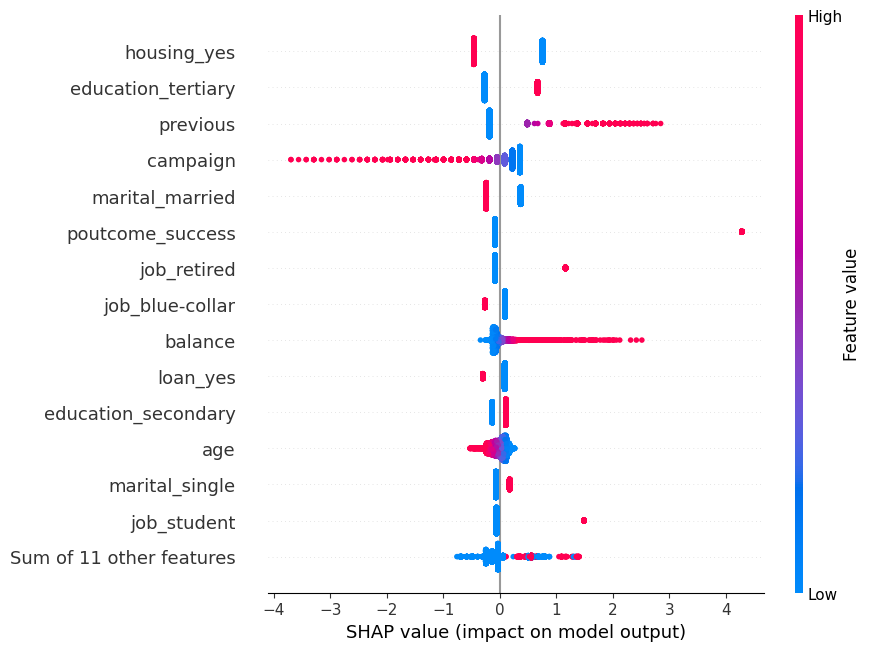

In [7]:
import shap

explainer_logreg = shap.Explainer(logreg_model, X_test)
shap_values_logreg = explainer_logreg(X_test)

shap.plots.beeswarm(shap_values_logreg, max_display=15)

### SHAP para Random Forest

In [ ]:
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test)

# For binary classification, use class 1 if shap returns a list
if isinstance(shap_values_rf, list):
    shap.summary_plot(shap_values_rf[1], X_test, max_display=15)
else:
    shap.summary_plot(shap_values_rf, X_test, max_display=15)

### SHAP para XGBoost

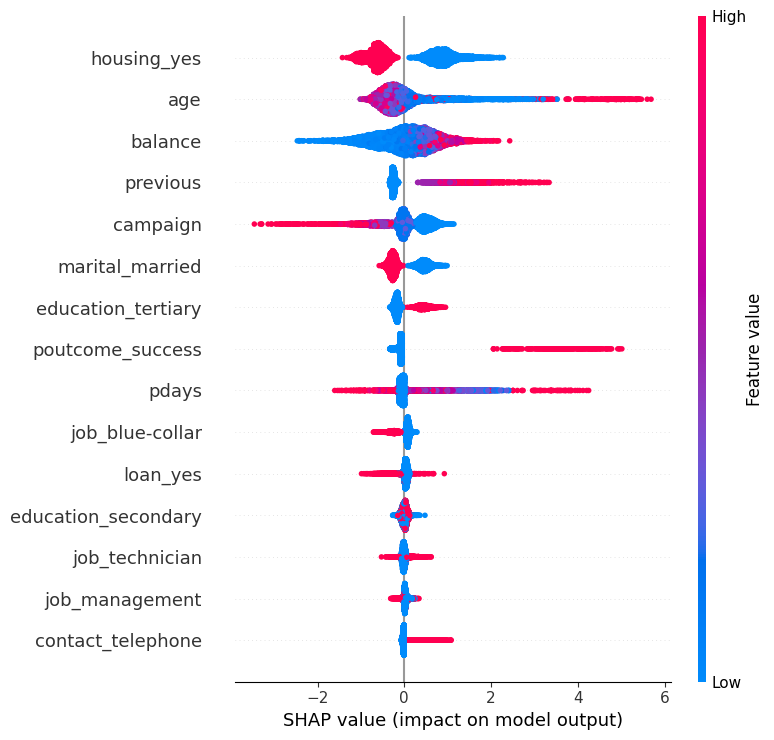

In [ ]:
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(shap_values_xgb, X_test, max_display=15)

## Guardar final predictions

In [ ]:
predictions_df = X_test.copy()
predictions_df["y_true"] = y_test.values

for model_name, preds in predictions_dict.items():
    safe_name = model_name.lower().replace(" ", "_")
    predictions_df[f"{safe_name}_pred"] = preds["y_pred"]
    predictions_df[f"{safe_name}_prob"] = preds["y_prob"]

predictions_df.to_csv(Path(r"data/test_set_predictions.csv"), index=False)

print("Predictions saved to data/test_set_predictions.csv")
display(predictions_df.head())

Predictions saved to data/test_set_predictions.csv


,age,balance,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,contact_telephone,poutcome_other,poutcome_success,y_true,logistic_regression_pred,logistic_regression_prob,random_forest_pred,random_forest_prob,xgboost_pred,xgboost_prob
0,0.285714,0.078614,0.016129,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,0,0.104612,0,0.060000,0,0.148486
1,0.337662,0.076235,0.016129,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,0,0.208074,0,0.003333,0,0.176525
2,0.168831,0.076035,0.064516,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,0,0.157358,0,0.033333,0,0.108799
3,0.233766,0.078750,0.048387,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,0,0.121326,0,0.056667,0,0.230407
4,0.207792,0.090244,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,0,0.450261,0,0.483333,0,0.458682
